In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Reshape
import matplotlib.dates as mdates

In [2]:
# 1. Load the Data
df = pd.read_csv('SHREECEM.csv')

# 2. Data Preprocessing
# Convert Date to datetime and sort
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

# Select exactly 11 numeric feature values for multi-output forecasting
features = [
    'Prev Close', 'Open', 'High', 'Low', 'Last', 
    'Close', 'VWAP', 'Volume', 'Turnover', 
    'Deliverable Volume', '%Deliverble'
]

# Handle any missing values (forward fill then backward fill)
df[features] = df[features].ffill().bfill()

# Extract dates for plotting later
dates = df['Date'].values
data = df[features].values

# Scale the data to (0, 1) range for LSTM
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

print("Data loaded and scaled successfully.")
print(f"Dataset shape: {data_scaled.shape}")

Data loaded and scaled successfully.
Dataset shape: (4985, 11)


In [3]:
# 3. Create Sequences
# Input: last 10 days, Output: predict next 5 days
seq_length = 10
forecast_horizon = 5
num_features = len(features)

X, y, y_dates = [], [], []

for i in range(len(data_scaled) - seq_length - forecast_horizon + 1):
    X.append(data_scaled[i : (i + seq_length)])
    y.append(data_scaled[(i + seq_length) : (i + seq_length + forecast_horizon)])
    y_dates.append(dates[(i + seq_length) : (i + seq_length + forecast_horizon)])

X = np.array(X)
y = np.array(y)
y_dates = np.array(y_dates)

# Split into Training (80%) and Testing (20%) sets
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test = y_dates[split:]

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing data shape: X={X_test.shape}, y={y_test.shape}")

Training data shape: X=(3976, 10, 11), y=(3976, 5, 11)
Testing data shape: X=(995, 10, 11), y=(995, 5, 11)


In [4]:
# 4. Build the LSTM Model
model = Sequential([
    LSTM(64, activation='relu', input_shape=(seq_length, num_features)),
    Dense(128, activation='relu'),
    # Output layer needs to output (forecast_horizon * num_features) values
    Dense(forecast_horizon * num_features),
    # Reshape back to (forecast_horizon, num_features)
    Reshape((forecast_horizon, num_features))
])

model.compile(optimizer='adam', loss='mse')
model.summary()

c:\Users\gauta\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 55)             │         7,095 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 5, 11)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,871 (136.21 KB)

 Trainable params: 34,871 (136.21 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 5. Train the Model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0098 - val_loss: 0.0062
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0024 - val_loss: 0.0044
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0024 - val_loss: 0.0039
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0024 - val_loss: 0.0046
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0024 - val_loss: 0.0038
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0024 - val_loss: 0.0039
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0024 - val_loss: 0.0039
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0024 - val_loss: 0.0044
Epoch 9/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0024 - val_loss: 0.0044
Epoch 10/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0024 - val_loss: 0.0045
Epoch 11/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0024 - val_loss: 0.0041
Epoch 12/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/ste

In [6]:
# 6. Make Predictions
y_pred_scaled = model.predict(X_test)

# Inverse transform predictions and true values to original scale
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, num_features)).reshape(y_pred_scaled.shape)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, num_features)).reshape(y_test.shape)

print("Predictions generated and inverse transformed.")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Predictions generated and inverse transformed.


In [7]:
# 7. Evaluate Performance (MSE, RMSE, MAE)
# Flattening arrays to compute overall metrics across all features and forecast days
y_pred_flat = y_pred.flatten()
y_test_flat = y_test_inv.flatten()

mse = mean_squared_error(y_test_flat, y_pred_flat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_flat, y_pred_flat)

print("\n--- Model Performance Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")


--- Model Performance Metrics ---
Mean Squared Error (MSE): 825866438905093613760282624.0000
Root Mean Squared Error (RMSE): 28737892040041.7266
Mean Absolute Error (MAE): 5222169098387.4043


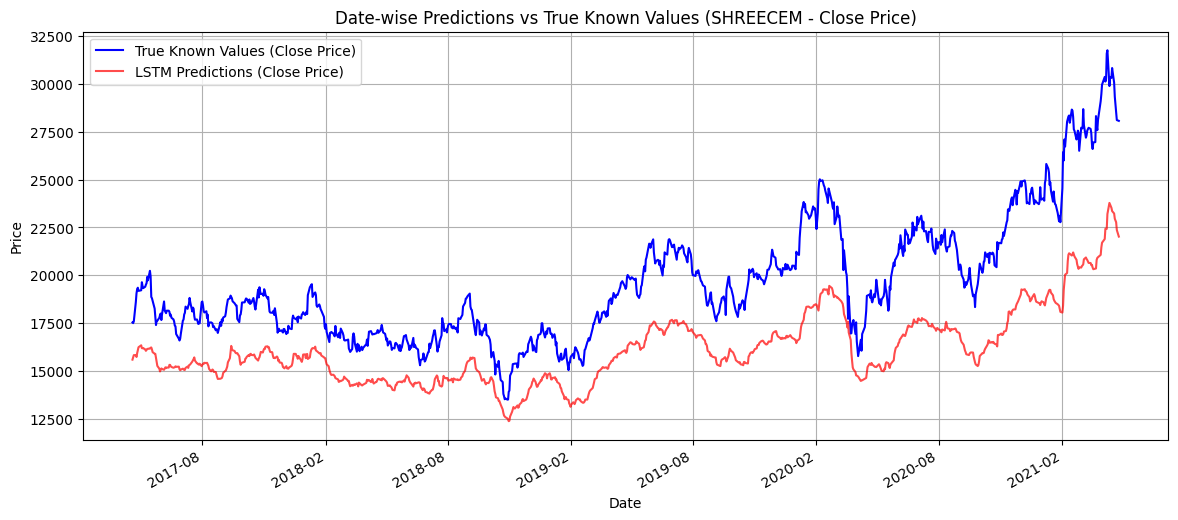

In [8]:
# 8. Plot Date-wise Predictions vs True Known Values
# Plotting specifically for the 'Close' price (index 5 in our feature list)
target_feature_idx = features.index('Close')

# We will plot the 1st step prediction of the forecast horizon across the test set
true_close = y_test_inv[:, 0, target_feature_idx]
pred_close = y_pred[:, 0, target_feature_idx]
plot_dates = pd.to_datetime(dates_test[:, 0])

plt.figure(figsize=(14, 6))
plt.plot(plot_dates, true_close, label='True Known Values (Close Price)', color='blue')
plt.plot(plot_dates, pred_close, label='LSTM Predictions (Close Price)', color='red', alpha=0.7)

plt.title('Date-wise Predictions vs True Known Values (SHREECEM - Close Price)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

# Formatting the x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gcf().autofmt_xdate()

plt.show()